# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the seminar notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [3]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [ ]:
# Install gymnasium if you didn't
# !pip install gymnasium[toy_text,classic_control]

/Users/v1adych/micromamba/envs/aim/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/Users/v1adych/micromamba/envs/aim/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


state vector dim = 4
n_actions = 2


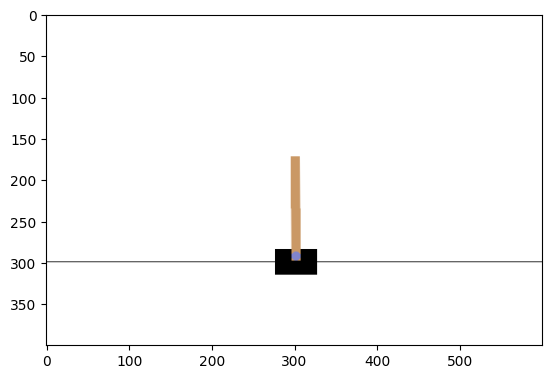

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [36]:
from sklearn.neural_network import MLPClassifier
import jax
from jax import numpy as jnp
from flax import nnx
agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)
# rngs = nnx.Rngs(0)
# agent = nnx.Sequential(
#     nnx.Linear(state_dim, 20, rngs=rngs),
#     nnx.tanh,
#     nnx.Linear(20, 20, rngs=rngs),
#     nnx.tanh,
#     nnx.Linear(20, n_actions, rngs=rngs),
# )

# initialize agent to the dimension of state space and number of actions
# The classes parameter must be passed on the first call to partial_fit
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))


,hidden_layer_sizes,"(20, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,None


In [19]:
agent.predict_proba([env.reset()[0]])

array([[0.50310002, 0.49689998]])

In [20]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        # logits = agent(jnp.asarray(s)[None, :])  # (1, A)
        # probs = np.array(jax.nn.softmax(logits, axis=-1)[0])
        probs = agent.predict_proba([s]).squeeze(0)

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(range(env.action_space.n), p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [21]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.02851767  0.04663534  0.01783262  0.03994465]
 [-0.02758497 -0.14873773  0.01863151  0.33820018]
 [-0.03055972  0.04611421  0.02539552  0.05145033]
 [-0.02963744  0.240863    0.02642452 -0.23311315]
 [-0.02482018  0.04537364  0.02176226  0.06778641]]
actions: [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1)]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [22]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # <YOUR CODE: copy-paste your implementation from the previous notebook>
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states, elite_actions = [], []
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])    # keep timestep order
            elite_actions.extend(actions_batch[i])  # keep timestep order

    return elite_states, elite_actions

# Training loop
Generate sessions, select N best and fit to those.

In [23]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 974.920, threshold=1000.000


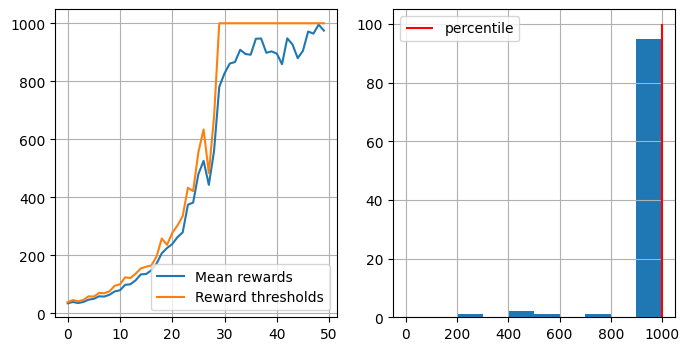

You Win! You may stop training now via KeyboardInterrupt.


In [24]:
n_sessions = 100
percentile = 70
log = []

for i in range(50):
    # generate new sessions
    # sessions = [ <YOUR CODE: generate a list of n_sessions new sessions> ]
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    # print([len(s[0]) for s in sessions])
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array([s[2] for s in sessions])

    # elite_states, elite_actions = <YOUR CODE: select elite actions just like before>
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>
    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [ ]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


In [ ]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (0.1 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (0.1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


In [147]:
from typing import Callable, Any


def _collect_rollout(policy: np.ndarray, env: gym.Env, num_steps: int):
    obs_seq = []
    action_seq = []
    total_return = 0.0

    obs, _ = env.reset()
    num_actions = policy.shape[1]

    for _ in range(num_steps):
        action = np.random.choice(num_actions, p=policy[obs])

        obs_seq.append(obs)
        action_seq.append(action)

        next_obs, reward, done, trunc, _ = env.step(action)
        total_return += reward

        obs = next_obs
        if done or trunc:
            break

    return np.array(obs_seq, dtype=np.int64), np.array(action_seq, dtype=np.int64), total_return


def run_experiment(
    num_updates: int,
    n_sessions: int,
    update_rule: Callable[[Any, np.ndarray, tuple, tuple, np.ndarray], tuple[Any, np.ndarray]],
    init_state: Any,
    env_name: str = "Taxi-v3",
    num_steps: int | None = None,
):
    env = gym.make(env_name)
    num_states = env.observation_space.n
    num_actions = env.action_space.n

    if num_steps is None:
        num_steps = env.spec.max_episode_steps

    policy = np.ones((num_states, num_actions), dtype=np.float64) / num_actions
    state = init_state
    returns_log = []

    for _ in range(num_updates):
        rollouts = [_collect_rollout(policy, env, num_steps) for _ in range(n_sessions)]
        obs_batch, actions_batch, returns_batch = zip(*rollouts)
        returns_batch = np.array(returns_batch, dtype=np.float64)
        returns_log.append(returns_batch)

        state, policy = update_rule(state, policy, obs_batch, actions_batch, returns_batch)

    return np.array(returns_log), state, policy


def cem_update(state, policy: np.ndarray, obs_batch, actions_batch, returns_batch: np.ndarray):
    percentile = state["percentile"]
    learning_rate = state["learning_rate"]

    threshold = np.percentile(returns_batch, percentile)
    counts = np.zeros_like(policy, dtype=np.float64)

    for obs_seq, act_seq, episode_return in zip(obs_batch, actions_batch, returns_batch):
        if episode_return >= threshold:
            for s, a in zip(obs_seq, act_seq):
                counts[s, a] += 1.0

    row_sums = counts.sum(axis=1, keepdims=True)
    target_policy = np.ones_like(policy, dtype=np.float64) / policy.shape[1]

    has_data = row_sums[:, 0] > 0
    target_policy[has_data] = counts[has_data] / row_sums[has_data]

    new_policy = (1.0 - learning_rate) * policy + learning_rate * target_policy
    return state, new_policy


def weighted_cem_update(state, policy: np.ndarray, obs_batch, actions_batch, returns_batch: np.ndarray):
    lr = state["learning_rate"]

    num_states, num_actions = policy.shape

    rewards_mean = returns_batch.mean()
    rewards_std = returns_batch.std()
    reward_normalized = (returns_batch - rewards_mean) / (rewards_std + 1e-8)
    weights = np.exp(reward_normalized)
    weights = weights / (weights.sum() + 1e-12)

    scores = np.zeros((num_states, num_actions), dtype=np.float64)
    for weight, obs_seq, act_seq in zip(weights, obs_batch, actions_batch):
        for s, a in zip(obs_seq, act_seq):
            scores[s, a] += weight

    new_policy = scores.copy()

    new_policy[np.sum(new_policy, axis=1) == 0] = 1
    new_policy = new_policy / np.sum(new_policy, axis=1, keepdims=True)

    new_policy = (1.0 - lr) * policy + lr * new_policy

    new_state = {
        "learning_rate": lr,
    }
    return new_state, new_policy


def plot_returns(results: np.ndarray, name: str, ax: plt.Axes):
    x = np.arange(results.shape[0])

    mean_returns = results.mean(axis=1)
    std_returns = results.std(axis=1)

    color = ax.plot(x, mean_returns, linewidth=2, label=name)[0].get_color()

    ax.fill_between(x, mean_returns - std_returns, mean_returns + std_returns, alpha=0.2, color=color)

    ax.set_xlabel("Update")
    ax.set_ylabel("Return")
    ax.set_title("Return evolution")
    ax.grid(alpha=0.3)
    ax.legend()

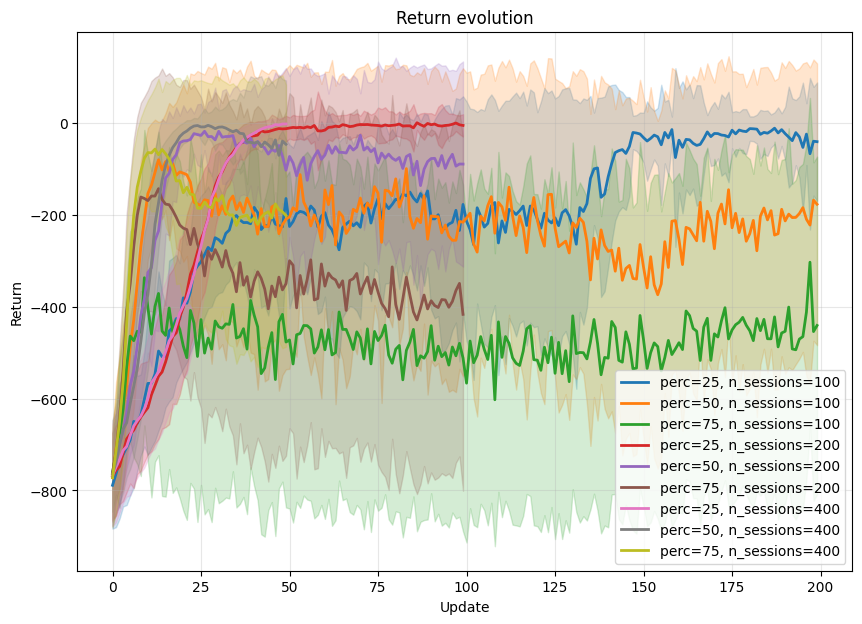

In [100]:
from itertools import product

num_updates = 100
num_sessions_base = 200
total_sessions = num_sessions_base * num_updates

results = {}
for n_sess_mult, perc in product([0.5, 1, 2], [25, 50, 75]):
    num_sessions = int(num_sessions_base * n_sess_mult)
    num_updates = total_sessions // num_sessions
    state = {
        "percentile": perc,
        "learning_rate": 0.5,
    }
    results[f"perc={perc}, n_sessions={num_sessions}"] = run_experiment(num_updates, num_sessions, cem_update, state)


plt.figure(figsize=(10, 7))
ax = plt.gca()

for name, (returns, _, _) in results.items():
    plot_returns(returns, name, ax)

plt.show()

In [148]:
init_state = {
    "learning_rate": 0.5,
}
results["weighted_cem"] = run_experiment(total_sessions // num_sessions_base, num_sessions_base, weighted_cem_update, init_state)

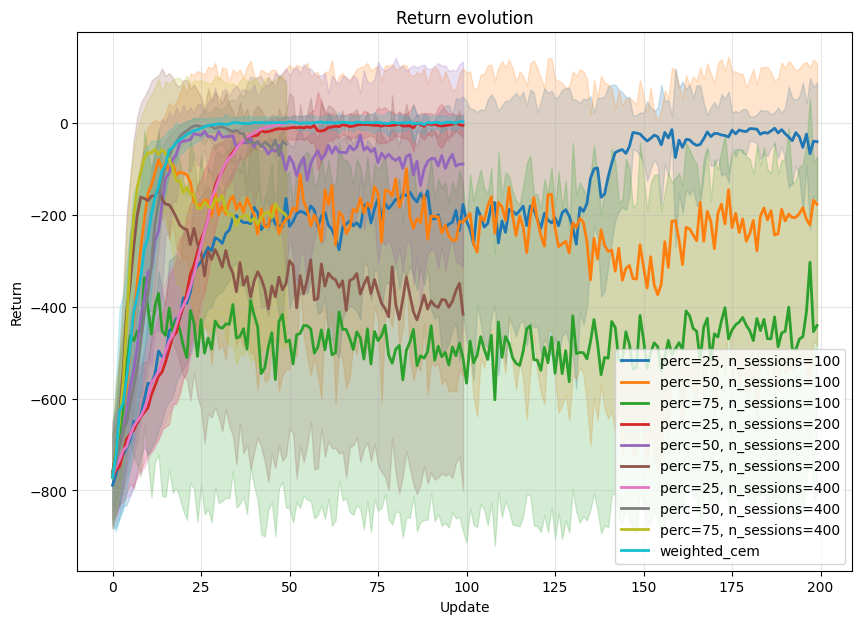

In [149]:
plt.figure(figsize=(10, 7))
ax = plt.gca()

for name, (returns, _, _) in results.items():
    plot_returns(returns, name, ax)

plt.show()

In [150]:
print(results["weighted_cem"][-1].mean())

0.16666666666666666


**Solution**: instead of hard filtering of all transitions from non-elite sessions, we can assign weights to each transition based on distribution of returns across the batch. Weighted CEM computes normalized episode returns and applies softmax to avoid negative values. Obtained scores are used for policy update

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (0.3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 0.5 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (0.1 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (0.2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (0.2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [3]:
from typing import Callable
import numpy as np
from sklearn.neural_network import MLPClassifier
import gymnasium as gym
from joblib import Parallel, delayed
from collections import deque


def run_experiment(
    num_updates: int,
    n_sessions: int,
    t_max: int,
    percentile_schedule: Callable[[float], float],
    env_id: str = "LunarLander-v3",
    rollout_collection_jobs: int = 1,
    rollout_lifetime: int = 1,
    hidden_sizes: tuple[int, ...] = (20, 20),
    weighted_cem: bool = False,
):
    env = gym.make(env_id, max_episode_steps=t_max)

    n_actions = int(env.action_space.n)

    policy = MLPClassifier(
        hidden_layer_sizes=hidden_sizes,
        activation="tanh",
    )

    policy.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

    def _collect_rollout(seed: int):
        env_local = gym.make(env_id, max_episode_steps=t_max)
        obs_seq, act_seq = [], []
        total_return = 0.0

        obs, _ = env_local.reset(seed=seed)

        for _ in range(t_max):
            probs = policy.predict_proba([obs])[0]
            action = np.random.choice(n_actions, p=probs)

            obs_seq.append(obs)
            act_seq.append(action)

            obs, reward, terminated, truncated, _ = env_local.step(action)
            total_return += float(reward)
            if terminated or truncated:
                break

        env_local.close()
        return np.asarray(obs_seq), np.asarray(act_seq), total_return

    returns_history = []
    rollout_window = deque(maxlen=max(1, rollout_lifetime))

    for upd in range(num_updates):
        # Fresh rollouts collected at this update.
        new_rollouts = Parallel(n_jobs=rollout_collection_jobs)(delayed(_collect_rollout)(seed=(10_000 * upd + i) % 2**31) for i in range(n_sessions))
        rollout_window.append(new_rollouts)

        # Keep the original history behavior: one row per update from fresh rollouts.
        _, _, current_returns = zip(*new_rollouts)
        current_returns = np.asarray(current_returns)

        mean_ret = float(current_returns.mean())
        best_ret = float(current_returns.max())
        returns_history.append(current_returns)

        # Pool rollouts from the last `rollout_lifetime` updates for thresholding + policy update.
        pooled_rollouts = [r for rollouts in rollout_window for r in rollouts]
        obs_batch, actions_batch, returns_batch = zip(*pooled_rollouts)
        returns_batch = np.asarray(returns_batch)

        percentile = percentile_schedule((upd + 1) / num_updates)
        threshold = np.percentile(returns_batch, percentile)
        print(f"Update {upd}: avg return {mean_ret:.2f}, best {best_ret:.2f}, percentile {percentile:.2f}, threshold {threshold:.2f}")

        if weighted_cem:
            rewards_mean = returns_batch.mean()
            rewards_std = returns_batch.std()
            reward_normalized = (returns_batch - rewards_mean) / (rewards_std + 1e-8)
            weights = np.exp(reward_normalized)
            weights = weights / (weights.sum() + 1e-12)

            elite_obs = []
            elite_actions = []
            elite_weights = []
            for obs, action, reward, weight in zip(obs_batch, actions_batch, returns_batch, weights):
                if reward >= threshold:
                    elite_obs.extend(obs)
                    elite_actions.extend(action)
                    elite_weights.extend(np.full(len(obs), weight).tolist())

            policy.partial_fit(elite_obs, elite_actions, sample_weight=elite_weights)

        else:
            elite_obs = []
            elite_actions = []
            for obs, action, reward in zip(obs_batch, actions_batch, returns_batch):
                if reward >= threshold:
                    elite_obs.extend(obs)
                    elite_actions.extend(action)

            policy.partial_fit(elite_obs, elite_actions)

    env.close()
    return np.stack(returns_history, axis=0)

def linear_decay(x: float, max_value: float, min_value: float) -> float:
    return min_value + (1 - x) * (max_value - min_value)

In [ ]:

returns = run_experiment(
    2000,
    64,
    1000,
    percentile_schedule=lambda x: linear_decay(x, 90, 85),
    rollout_collection_jobs=32,
    rollout_lifetime=5,
    hidden_sizes=(64, 64),
)

/Users/v1adych/micromamba/envs/aim/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/v1adych/micromamba/envs/aim/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/v1adych/micromamba/envs/aim/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources packa

Update 0: avg return -155.31, best 43.57, percentile 90.00, threshold -82.81
Update 1: avg return -140.82, best -17.67, percentile 90.00, threshold -79.72
Update 2: avg return -175.20, best -18.68, percentile 89.99, threshold -79.76
Update 3: avg return -161.00, best -40.11, percentile 89.99, threshold -79.71
Update 4: avg return -134.66, best 9.37, percentile 89.99, threshold -79.66
Update 5: avg return -126.11, best 25.72, percentile 89.98, threshold -79.74
Update 6: avg return -137.81, best -35.68, percentile 89.98, threshold -79.86
Update 7: avg return -119.07, best 29.03, percentile 89.98, threshold -72.63
Update 8: avg return -127.51, best 6.96, percentile 89.98, threshold -68.84
Update 9: avg return -138.64, best 53.69, percentile 89.97, threshold -68.85
Update 10: avg return -145.38, best 35.13, percentile 89.97, threshold -65.13
Update 11: avg return -133.44, best -4.40, percentile 89.97, threshold -61.42
Update 12: avg return -123.70, best -4.95, percentile 89.97, threshold -

In [9]:
from matplotlib import pyplot as plt


def plot_returns(results: np.ndarray, name: str, ax: plt.Axes):
    x = np.arange(results.shape[0])

    mean_returns = results.mean(axis=1)
    perc_pairs = [
        (5, 0.1),
        (15, 0.2),
        (25, 0.3),
        (40, 0.4)
    ]

    color = ax.plot(x, mean_returns, linewidth=2, label=name)[0].get_color()
    for perc_lower, alpha in perc_pairs:
        perc_upper = 100 - perc_lower
        q_low = np.percentile(results, perc_lower, axis=1)
        q_high = np.percentile(results, perc_upper, axis=1)
        ax.fill_between(x, q_low, q_high, alpha=alpha, color=color)

    ax.set_xlabel("Update")
    ax.set_ylabel("Return")
    ax.set_title("Return evolution")
    ax.grid(alpha=0.3)
    ax.legend()


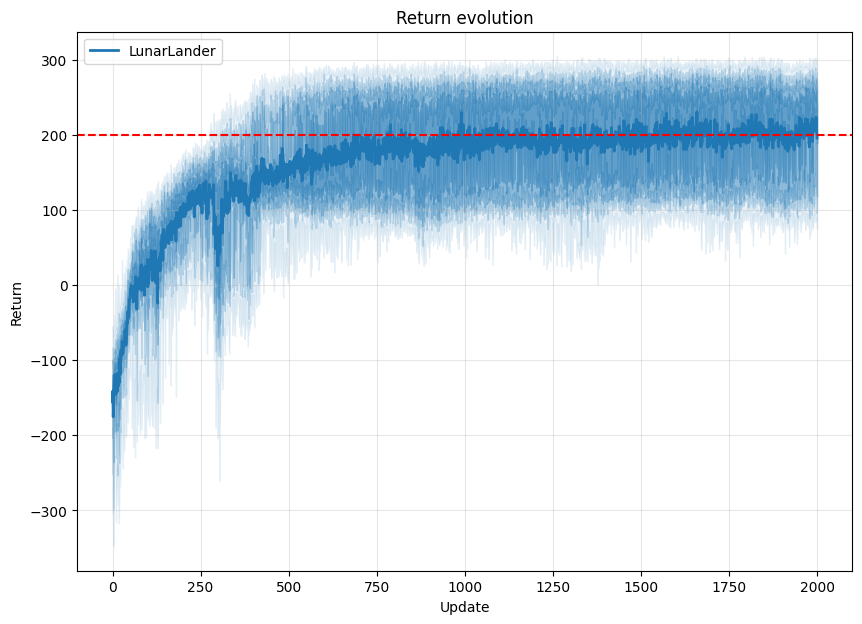

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_returns(returns, "LunarLander", ax)
ax.axhline(200, color="red", linestyle="--")

### Bonus tasks

* __2.3 bonus__ (0.2 pts) Try to find a network architecture and training params that solve __both__ environments above. 

* __2.4 bonus__ (0.3 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 0.3 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

In [ ]:
returns_car = run_experiment(
    2000,
    64,
    10000,
    percentile_schedule=lambda x: linear_decay(x, 90, 85),
    rollout_collection_jobs=32,
    rollout_lifetime=5,
    hidden_sizes=(64, 64),
    env_id="MountainCar-v0",
)

Update 0: avg return -9552.30, best -1493.00, percentile 90.00, threshold -9962.29
Update 1: avg return -8939.23, best -1622.00, percentile 90.00, threshold -6332.48
Update 2: avg return -9640.31, best -3271.00, percentile 89.99, threshold -6634.73
Update 3: avg return -9084.31, best -1245.00, percentile 89.99, threshold -6463.13
Update 4: avg return -8629.72, best -696.00, percentile 89.99, threshold -6123.44
Update 5: avg return -8908.38, best -1758.00, percentile 89.98, threshold -5280.31
Update 6: avg return -7825.73, best -1966.00, percentile 89.98, threshold -4520.99
Update 7: avg return -7153.81, best -921.00, percentile 89.98, threshold -3589.78
Update 8: avg return -4787.66, best -1043.00, percentile 89.98, threshold -2717.39
Update 9: avg return -5032.98, best -1053.00, percentile 89.97, threshold -2379.90
Update 10: avg return -3361.56, best -658.00, percentile 89.97, threshold -1932.99
Update 11: avg return -2182.92, best -746.00, percentile 89.97, threshold -1483.00
Update

(-200.0, 0.0)

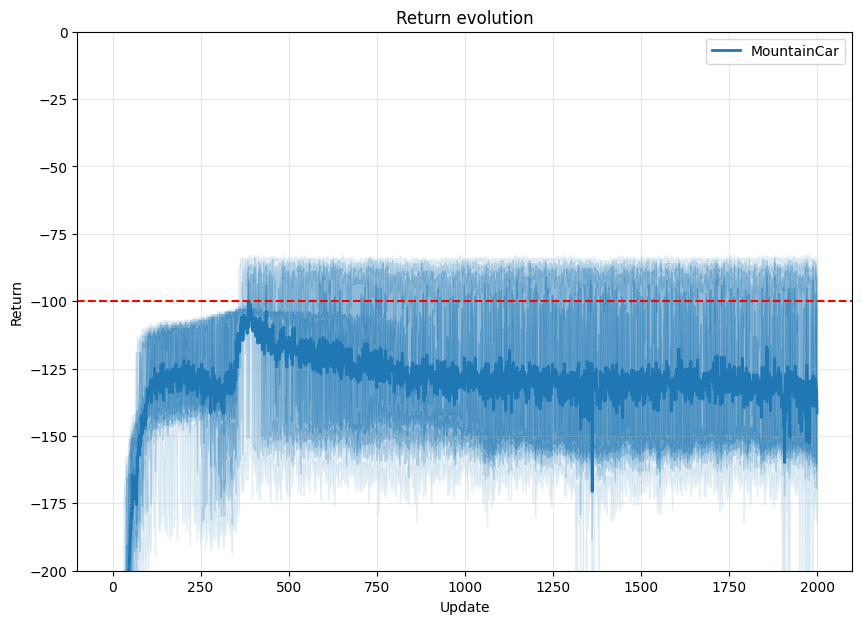

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_returns(returns_car, "MountainCar", ax)
ax.axhline(-100, color="red", linestyle="--")
ax.set_ylim(-200, 0)